# `GenVarLoader`

In [2]:
# Automatically reload code in notebook
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd
import polars as pl
# pip install git+https://github.com/mcvickerlab/GenVarLoader.git@dlaub/dlaub-splice --force-reinstall
import genvarloader as gvl
import seqpro as sp
import pooch
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.genvarloader as GVL

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Test splicing

https://github.com/mcvickerlab/GenVarLoader/blob/dlaub/splice/docs/source/splicing.ipynb

### Import GTF

In [3]:
# From Ensembl FTP: https://ftp.ensembl.org/pub/release-113/gtf/homo_sapiens/
gtf_path = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-113/gtf/homo_sapiens/Homo_sapiens.GRCh38.113.chr_patch_hapl_scaff.gtf.gz",
    known_hash="670d0572422b315124770d1dff1613ff5b563b965de48d8f35cccdef892bfc35",
    progressbar=True,
    fname="Homo_sapiens.GRCh38.113.chr_patch_hapl_scaff.gtf.gz",
)

In [4]:
import gtfparse

gtf = gtfparse.read_gtf(
    gtf_path,
    features=["exon"]
    )
gtf.head()

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'transcript_id', 'transcript_version', 'exon_number', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_name', 'transcript_source', 'transcript_biotype', 'exon_id', 'exon_version', 'tag', 'transcript_support_level', 'ccds_id']


seqname,source,feature,start,end,score,strand,frame,gene_id,gene_version,transcript_id,transcript_version,exon_number,gene_name,gene_source,gene_biotype,transcript_name,transcript_source,transcript_biotype,exon_id,exon_version,tag,transcript_support_level,ccds_id
cat,cat,cat,i64,i64,f32,cat,u32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1""","""havana""","""exon""",3069168,3069296,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""1""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00002048533""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3186125,3186474,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""2""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00001754112""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3244087,3244137,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""3""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00003480863""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3385149,3385286,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""4""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00002034212""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3396491,3396593,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""5""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00003700221""","""1""","""gencode_basic,gencode_primary""","""5""",""""""


### Import Haplotypes: Haplosaurus

In [5]:
haplotypes = hs.get_haplotypes(cache_only=True)

Found 557 haplotypes in: '/grid/koo/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes: 100%|██████████| 557/557 [00:24<00:00, 22.42it/s]


In [ ]:
chr22_genes = (
    gtf
    # .filter(pl.col("transcript_id").is_in(haplotypes.keys()  ))
    .filter(pl.col("seqname") == "22")
    .filter(pl.col("feature") == "exon")
    .rename({"seqname": "chrom", "start": "chromStart", "end": "chromEnd"})
    .with_columns(
        pl.col("strand").cast(pl.Utf8),
        pl.col("exon_version").cast(pl.Int32),
        pl.col("exon_number").cast(pl.Int32), # <<-- IMPORTANT: this MUST be an integer (not string) to get exon orders correct
        pl.col("transcript_version").cast(pl.Int32),
        pl.col("gene_version").cast(pl.Int32),
    )
)
chr22_genes.head()

chrom,source,feature,chromStart,chromEnd,score,strand,frame,gene_id,gene_version,transcript_id,transcript_version,exon_number,gene_name,gene_source,gene_biotype,transcript_name,transcript_source,transcript_biotype,exon_id,exon_version,tag,transcript_support_level,ccds_id
cat,cat,cat,i64,i64,f32,str,u32,str,i32,str,i32,i32,str,str,str,str,str,str,str,i32,str,str,str
"""22""","""havana""","""exon""",15298378,15304556,null,"""-""",0,"""ENSG00000279442""",1,"""ENST00000623199""",1,1,"""""","""havana""","""lncRNA""","""""","""havana""","""lncRNA""","""ENSE00003755131""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",11124337,11124379,null,"""+""",0,"""ENSG00000226444""",2,"""ENST00000422332""",1,1,"""ACTR3BP7""","""havana""","""processed_pseudogene""","""ACTR3BP7-201""","""havana""","""processed_pseudogene""","""ENSE00001616995""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",11124508,11125705,null,"""+""",0,"""ENSG00000226444""",2,"""ENST00000422332""",1,2,"""ACTR3BP7""","""havana""","""processed_pseudogene""","""ACTR3BP7-201""","""havana""","""processed_pseudogene""","""ENSE00001776473""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",15290718,15290836,null,"""+""",0,"""ENSG00000236235""",1,"""ENST00000448473""",1,1,"""""","""havana""","""unprocessed_pseudogene""","""""","""havana""","""unprocessed_pseudogene""","""ENSE00001782524""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",15290995,15291024,null,"""+""",0,"""ENSG00000236235""",1,"""ENST00000448473""",1,2,"""""","""havana""","""unprocessed_pseudogene""","""""","""havana""","""unprocessed_pseudogene""","""ENSE00001723295""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""


### Download VCF

In [7]:
# From 1KG FTP: https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/


#### High Coverage
# Download the VCF file
# vcf_path = pooch.retrieve(
#     url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/20220422_3202_phased_SNV_INDEL_SV/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz",
#     known_hash="91aeaf0d1e805cf4223c5cbf12e22afc28db1709054c42bd668337219f8fddcc",
#     progressbar=True,
#     fname="1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz",
# )

# # Download the index file
# pooch.retrieve(
#     url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/20220422_3202_phased_SNV_INDEL_SV/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz.tbi",
#     known_hash="016cbb66398337629e4b06de238703a17bbfbc25f48f7f660876e8968e2da4de",
#     progressbar=True,
#     fname="1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz.tbi",
# )

#### Low Coverage
vcf_path = pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20190312_biallelic_SNV_and_INDEL/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz",
    known_hash="SHA256:dc2b718c00d1a8220f19561bc647eea08fc25ce641c8f2c12e540fb31f073f88",
    progressbar=True,
    fname="ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz",
)

# Download the index file
pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20190312_biallelic_SNV_and_INDEL/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz.tbi",
    known_hash="SHA256:0511a26b9b132dd60e229aa1f89f4d5ebda1dabbe068373f7628a20854e9730d",
    progressbar=True,
    fname="ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz.tbi",
)

vcf_path

'/grid/koo/home/schilder/.cache/pooch/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz'

### Download reference genome

In [8]:
# This is the correct reference genome for all 1KG data aligned to GRCh38

# Download the reference genome fasta
reference = pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa",
    known_hash="SHA256:3b103f4742abfd54938fb0333e19ad067635c8eb86f1dbf0ce44b165c4292b50",
    progressbar=True,
)

# Download the reference genome fasta index
pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai",
    known_hash="SHA256:f361f004bdae5ca68d632458b01a3848d02834ac7176f378e177344d148a6a6d",
    progressbar=True,
)

'/grid/koo/home/schilder/.cache/pooch/871f2eeba15bb736cd4958c34b3569b9-GRCh38_full_analysis_set_plus_decoy_hla.fa.fai'

#### Convert the VCF --> BCF --> PGEN
Filter SNPs and indels, and convert to BCF.
This step is only necessary for the high-coverage 1KG dataset because it includes more complex forms a variation (e.g. structural variants).

In [ ]:
# Filter SNPs and indels, and convert to BCF
import subprocess

# Define output paths
output_path = vcf_path.replace(".vcf.gz", "")
bcf_path = output_path + ".bcf"
pgen_path = output_path
bctools = "bcftools"#"/grid/it/data/elzar/easybuild/software/BCFtools/1.19-GCC-13.2.0/bin/bcftools"
plink2 = "plink2"

# Run bcftools to filter and normalize variants

# Construct the command
cmd = [
    "module load EBModules BCFtools","&&",
    f"{bctools}", "view", "-i", '\'TYPE="snp" || TYPE="indel"\'', "-O", "u", vcf_path,"|",
    f"{bctools}", "norm", "-f", reference, "-a", "--atom-overlaps", ".", "-m", "-", "-O", "b", "-o", bcf_path
]

# Print the command
print(" ".join(cmd))

# Run the command
# subprocess.run(cmd, capture_output=True, check=True)

# # Convert to PLINK PGEN format
cmd2 = [
    plink2, "--make-pgen", "--bcf", bcf_path, "--out", pgen_path
]
# subprocess.run(cmd2, check=True)

bcftools view -i 'TYPE="snp,indel"' -O u /grid/koo/home/schilder/.cache/pooch/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz | bcftools norm -f /grid/koo/home/schilder/.cache/pooch/296ca04ba1df562072adc4c76f64cfb9-GRCh38_full_analysis_set_plus_decoy_hla.fa -a --atom-overlaps . -m - -O b -o /grid/koo/home/schilder/.cache/pooch/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.bcf


### Create GVL database

In [14]:
gvl_path = "/grid/koo/home/schilder/projects/1kg_chr22.gvl"
force = False
if not os.path.exists(gvl_path) or force:
    gvl.write(
        path=gvl_path,
        bed=chr22_genes,
        variants=vcf_path, #"/grid/koo/home/schilder/projects/ProHap/chr22.pgen",
        max_jitter=0,
        overwrite=True
    )

Writing genotypes for 1968 regions on chromosome 22: 100%|██████████| 11/11 [12:16<00:00, 67.00s/it]
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
ds = gvl.Dataset.open(gvl_path, 
                       reference=reference,
                       splice_info=('transcript_id', 'exon_number'))

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/genvarloader/_variants/_records.py:109: DeprecationWarning: `ExprStringNameSpace.concat` is deprecated. Use `str.join` instead. Note that the default `delimiter` for `str.join` is an empty string instead of a hyphen.
  alleles.str.concat("").to_numpy()[0].encode(), "S1"


In [16]:
ds.regions

chrom,source,feature,chromStart,chromEnd,score,strand,frame,gene_id,gene_version,transcript_id,transcript_version,exon_number,gene_name,gene_source,gene_biotype,transcript_name,transcript_source,transcript_biotype,exon_id,exon_version,tag,transcript_support_level,ccds_id
cat,cat,cat,i64,i64,f32,str,u32,str,i32,str,i32,i32,str,str,str,str,str,str,str,i32,str,str,str
"""22""","""havana""","""exon""",15298378,15304556,null,"""-""",0,"""ENSG00000279442""",1,"""ENST00000623199""",1,1,"""""","""havana""","""lncRNA""","""""","""havana""","""lncRNA""","""ENSE00003755131""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",11124337,11124379,null,"""+""",0,"""ENSG00000226444""",2,"""ENST00000422332""",1,1,"""ACTR3BP7""","""havana""","""processed_pseudogene""","""ACTR3BP7-201""","""havana""","""processed_pseudogene""","""ENSE00001616995""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",11124508,11125705,null,"""+""",0,"""ENSG00000226444""",2,"""ENST00000422332""",1,2,"""ACTR3BP7""","""havana""","""processed_pseudogene""","""ACTR3BP7-201""","""havana""","""processed_pseudogene""","""ENSE00001776473""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",15290718,15290836,null,"""+""",0,"""ENSG00000236235""",1,"""ENST00000448473""",1,1,"""""","""havana""","""unprocessed_pseudogene""","""""","""havana""","""unprocessed_pseudogene""","""ENSE00001782524""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
"""22""","""havana""","""exon""",15290995,15291024,null,"""+""",0,"""ENSG00000236235""",1,"""ENST00000448473""",1,2,"""""","""havana""","""unprocessed_pseudogene""","""""","""havana""","""unprocessed_pseudogene""","""ENSE00001723295""",1,"""gencode_basic,Ensembl_canonica…","""NA""",""""""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""22""","""havana_tagene""","""exon""",17020574,17020797,null,"""-""",0,"""ENSG00000295065""",1,"""ENST00000727726""",1,3,"""""","""havana_tagene""","""lncRNA""","""""","""havana_tagene""","""lncRNA""","""ENSE00004053500""",1,"""""","""""",""""""
"""22""","""havana_tagene""","""exon""",17024358,17024498,null,"""-""",0,"""ENSG00000295065""",1,"""ENST00000727727""",1,1,"""""","""havana_tagene""","""lncRNA""","""""","""havana_tagene""","""lncRNA""","""ENSE00004053499""",1,"""gencode_basic""","""""",""""""
"""22""","""havana_tagene""","""exon""",17024055,17024174,null,"""-""",0,"""ENSG00000295065""",1,"""ENST00000727727""",1,2,"""""","""havana_tagene""","""lncRNA""","""""","""havana_tagene""","""lncRNA""","""ENSE00004053497""",1,"""gencode_basic""","""""",""""""


In [17]:
ds.spliced_regions

splice_id,regions,chrom,chromStart,chromEnd,strand,source,feature,score,frame,gene_id,gene_version,transcript_id,transcript_version,exon_number,gene_name,gene_source,gene_biotype,transcript_name,transcript_source,transcript_biotype,exon_id,exon_version,tag,transcript_support_level,ccds_id
str,list[u32],cat,list[i64],list[i64],str,list[cat],list[cat],list[f32],list[u32],list[str],list[i32],list[str],list[i32],list[i32],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[i32],list[str],list[str],list[str]
"""ENST00000006251""",[0],"""22""",[15298378],[15304556],"""-""","[""havana""]","[""exon""]",[null],[0],"[""ENSG00000279442""]",[1],"[""ENST00000623199""]",[1],[1],"[""""]","[""havana""]","[""lncRNA""]","[""""]","[""havana""]","[""lncRNA""]","[""ENSE00003755131""]",[1],"[""gencode_basic,Ensembl_canonical""]","[""NA""]","[""""]"
"""ENST00000008876""","[1, 2]","""22""","[11124337, 11124508]","[11124379, 11125705]","""+""","[""havana"", ""havana""]","[""exon"", ""exon""]","[null, null]","[0, 0]","[""ENSG00000226444"", ""ENSG00000226444""]","[2, 2]","[""ENST00000422332"", ""ENST00000422332""]","[1, 1]","[1, 2]","[""ACTR3BP7"", ""ACTR3BP7""]","[""havana"", ""havana""]","[""processed_pseudogene"", ""processed_pseudogene""]","[""ACTR3BP7-201"", ""ACTR3BP7-201""]","[""havana"", ""havana""]","[""processed_pseudogene"", ""processed_pseudogene""]","[""ENSE00001616995"", ""ENSE00001776473""]","[1, 1]","[""gencode_basic,Ensembl_canonical"", ""gencode_basic,Ensembl_canonical""]","[""NA"", ""NA""]","["""", """"]"
"""ENST00000043402""","[3, 4, … 7]","""22""","[15290718, 15290995, … 15297157]","[15290836, 15291024, … 15297196]","""+""","[""havana"", ""havana"", … ""havana""]","[""exon"", ""exon"", … ""exon""]","[null, null, … null]","[0, 0, … 0]","[""ENSG00000236235"", ""ENSG00000236235"", … ""ENSG00000236235""]","[1, 1, … 1]","[""ENST00000448473"", ""ENST00000448473"", … ""ENST00000448473""]","[1, 1, … 1]","[1, 2, … 5]","["""", """", … """"]","[""havana"", ""havana"", … ""havana""]","[""unprocessed_pseudogene"", ""unprocessed_pseudogene"", … ""unprocessed_pseudogene""]","["""", """", … """"]","[""havana"", ""havana"", … ""havana""]","[""unprocessed_pseudogene"", ""unprocessed_pseudogene"", … ""unprocessed_pseudogene""]","[""ENSE00001782524"", ""ENSE00001723295"", … ""ENSE00001734865""]","[1, 1, … 1]","[""gencode_basic,Ensembl_canonical"", ""gencode_basic,Ensembl_canonical"", … ""gencode_basic,Ensembl_canonical""]","[""NA"", ""NA"", … ""NA""]","["""", """", … """"]"
"""ENST00000086933""","[8, 9, 10]","""22""","[11474744, 11475146, 11477178]","[11474904, 11475238, 11479643]","""+""","[""havana"", ""havana"", ""havana""]","[""exon"", ""exon"", ""exon""]","[null, null, null]","[0, 0, 0]","[""ENSG00000288262"", ""ENSG00000288262"", ""ENSG00000288262""]","[1, 1, 1]","[""ENST00000672261"", ""ENST00000672261"", ""ENST00000672261""]","[1, 1, 1]","[1, 2, 3]","[""ZNF73P"", ""ZNF73P"", ""ZNF73P""]","[""havana"", ""havana"", ""havana""]","[""unprocessed_pseudogene"", ""unprocessed_pseudogene"", ""unprocessed_pseudogene""]","[""ZNF73P-201"", ""ZNF73P-201"", ""ZNF73P-201""]","[""havana"", ""havana"", ""havana""]","[""unprocessed_pseudogene"", ""unprocessed_pseudogene"", ""unprocessed_pseudogene""]","[""ENSE00003893399"", ""ENSE00003891926"", ""ENSE00003892093""]","[1, 1, 1]","[""gencode_basic,Ensembl_canonical"", ""gencode_basic,Ensembl_canonical"", ""gencode_basic,Ensembl_canonical""]","["""", """", """"]","["""", """", """"]"
"""ENST00000155674""",[11],"""22""",[15349467],[15350043],"""+""","[""havana""]","[""exon""]",[null],[0],"[""ENSG00000236097""]",[1],"[""ENST00000441221""]",[1],[1],"[""BNIP3P2""]","[""havana""]","[""processed_pseudogene""]","[""BNIP3P2-201""]","[""havana""]","[""processed_pseudogene""]","[""ENSE00001722896""]",[1],"[""gencode_basic,Ensembl_canonical""]","[""NA""]","[""""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENST00000849656""","[45885, 45886]","""22""","[17022349, 17021398]","[17022570, 17022

In [18]:
tx_ids = utils.intersect(haplotypes.keys(), 
                         ds.spliced_regions['splice_id'].to_list())
print(len(tx_ids),"overlapping tx_ids")

6 overlapping tx_ids


In [19]:

tx_sample_seqs = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                          tx_ids=tx_ids, 
                                          samples=ds.samples, 
                                          cohort="1000GENOMES:phase_3")
tx_seq_counts, total_counts = hs.count_haplotype_samples(tx_sample_seqs)
tx_seq_counts


Total sequence length counts across all transcripts:
Counter({2: 15018, 0: 270})


{'ENST00000216181': Counter({2: 2503, 0: 45}),
 'ENST00000357068': Counter({2: 2503, 0: 45}),
 'ENST00000263253': Counter({2: 2503, 0: 45}),
 'ENST00000248846': Counter({2: 2503, 0: 45}),
 'ENST00000314328': Counter({2: 2503, 0: 45}),
 'ENST00000216122': Counter({2: 2503, 0: 45})}

In [ ]:
# Call the function to calculate similarities
seq_sim = GVL.calculate_sequence_similarities(ds=ds, 
                                                        tx_sample_seqs=tx_sample_seqs, 
                                                        tx_ids=tx_ids,
                                                        add_exonic=True
                                                        )
print(seq_sim.shape)
seq_sim.head()

Processing transcripts: 100%|██████████| 6/6 [08:38<00:00, 86.35s/it] 


(450540, 14)


/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transcript_id,gene_name,exon_count,sample,seq1,seq2,seq1_len,seq2_len,seq_sim,seq1_phase,seq2_phase,phase_match,group1,group2
0,ENST00000216181,ENTHD1,2,HG01133,GVL[0],GVL[1],452,452,0.615044,0,1,False,GVL,GVL
1,ENST00000216181,ENTHD1,2,HG01133,GVL[0],HS[0],452,5883,0.142699,0,0,True,GVL,HS
2,ENST00000216181,ENTHD1,2,HG01133,GVL[0],HS[1],452,5883,0.142699,0,1,False,GVL,HS
3,ENST00000216181,ENTHD1,2,HG01133,GVL[0],GVLex[0],452,452,1.000000,0,0,True,GVL,GVLex
4,ENST00000216181,ENTHD1,2,HG01133,GVL[0],GVLex[1],452,452,0.615044,0,1,False,GVL,GVLex


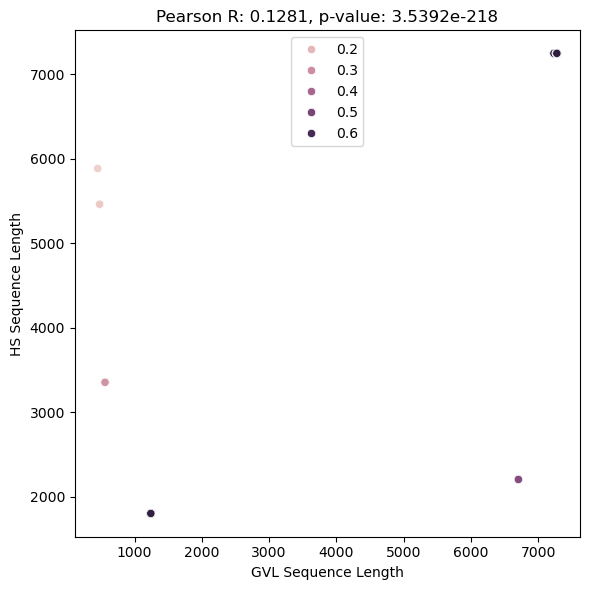

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
plot_data = seq_sim.loc[(seq_sim['group1'] == 'GVL') & (seq_sim['group2'] == 'HS')]

# Calculate Pearson correlation coefficient and p-value
from scipy.stats import pearsonr
r, p = pearsonr(plot_data['seq1_len'], plot_data['seq2_len'])
title = f'Pearson R: {r:.4f}, p-value: {p:.4e}'

# Create scatter plot with correlation info in title
plt.figure(figsize=(6, 6))
scatter = sns.scatterplot(data=plot_data, 
                          x='seq1_len', y='seq2_len', hue='seq_sim')
plt.title(title)
# Move the legend to the top and make it horizontal
plt.legend(loc='upper center')
plt.xlabel('GVL Sequence Length')
plt.ylabel('HS Sequence Length')
plt.tight_layout()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

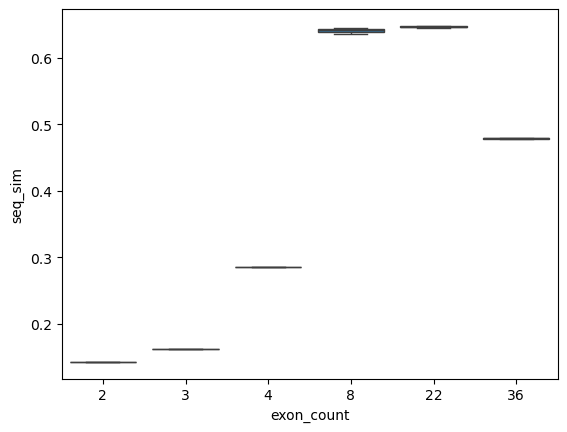

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
scatter = sns.boxplot(data=plot_data, 
                      x='exon_count', y='seq_sim')
                          

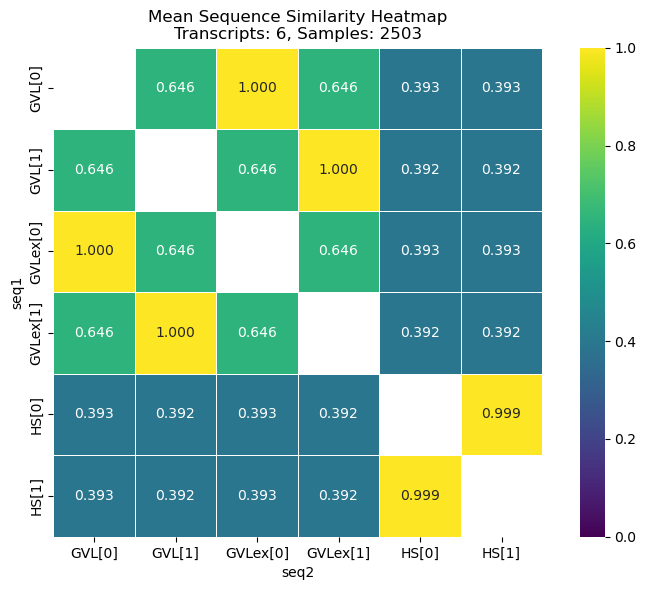

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# Create a pivot table for the heatmap
mean_sim_mtx = seq_sim.groupby(['seq1', 'seq2']).agg({'seq_sim': 'mean'}).reset_index().pivot_table(
    index='seq1', 
    columns='seq2', 
    values='seq_sim'
)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(mean_sim_mtx, annot=True, cmap='viridis', vmin=0, vmax=1, 
            linewidths=.5, fmt='.3f', square=True)
plt.title(f'Mean Sequence Similarity Heatmap\nTranscripts: {seq_sim['transcript_id'].nunique()}, Samples: {seq_sim['sample'].nunique()}')
plt.tight_layout()
plt.show()


/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Figure size 600x1000 with 0 Axes>

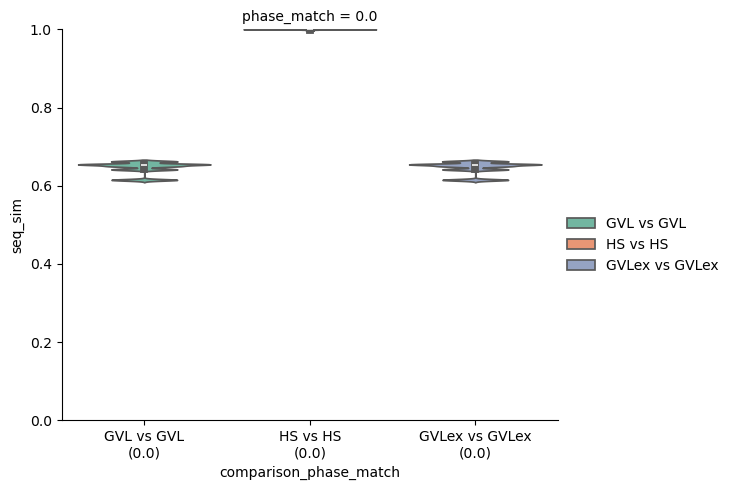

In [32]:
import numpy as np
# Sort the groups alphabetically to make the comparison invariant to order
seq_sim['comparison'] = np.where(
    seq_sim['group1'] < seq_sim['group2'],
    seq_sim['group1'] + ' vs ' + seq_sim['group2'],
    seq_sim['group2'] + ' vs ' + seq_sim['group1']
)
seq_sim['comparison_phase_match'] = seq_sim['comparison'] + '\n(' + seq_sim['phase_match'].astype(str) + ')'

# Create separate violin plots for each phase_match value
plt.figure(figsize=(6, 10))

# Alternatively, we can create a facetgrid to show separate plots by phase_match
g = sns.FacetGrid(seq_sim, row='phase_match', height=5, aspect=1.2)
g.map_dataframe(sns.violinplot, x='comparison_phase_match', y='seq_sim', hue='comparison', palette="Set2")
g.set(ylim=(0, 1))  # Set y-axis limits from 0 to 1
g.add_legend()
